# **MACHINE LEARNING**
## **Naive Bayes — Análisis de Sentimientos (Google Play Reviews)**

# **PASO 1: Carga del conjunto de datos**

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import joblib
import os

In [79]:
# Carga del dataset desde GitHub
url = "https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv"
df = pd.read_csv(url)

print(df.shape)
df.head(10)

(891, 3)


,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0
5,com.facebook.katana,idk i can't edit my posts? things such as my ...,0
6,com.facebook.katana,major flaws constant updates and always getti...,0
7,com.facebook.katana,video issues since i was forced into this upd...,0
8,com.facebook.katana,this update completely destroyed my facebook...,0
9,com.facebook.katana,"posting issues for the last week, there's bee...",0


El dataset tiene **614 filas y 3 columnas**:
- `package_name`: nombre de la app (No nos va a servir para predecir sentimientos)
- `review`: texto del comentario (La única predictora)
- `polarity`: 0 = negativo, 1 = positivo (Variable  objetivo, sí aporta)

# **PASO 2: Estudio de variables y preprocesamiento del texto**

## 2.1 Inspección inicial

In [81]:
print("INFORMACIÓN GENERAL DEL DATASET")
df.info()

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   package_name  891 non-null    object
 1   review        891 non-null    object
 2   polarity      891 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 21.0+ KB


Este dataset no tiene valores nulos y las tres columnas son de tipo `object` menos la columna `polarity`, que es numérica.

In [82]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n Total valores nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
package_name    0
review          0
polarity        0
dtype: int64

 Total valores nulos: 0


El dataset tiene **0 valores nulos** en ninguna columna, tenemos 614 reseñas.

## 2.2 Eliminación de la columna `package_name`

In [83]:
# La variable package_name no aporta información para predecir el sentimiento
# El sentimiento depende del contenido del comentario, no de la app en cuestión
df = df.drop(columns=["package_name"])
print("Columnas restantes:", df.columns.tolist())
df.head()

Columnas restantes: ['review', 'polarity']


,review,polarity
0,privacy at least put some option appear offli...,0
1,"messenger issues ever since the last update, ...",0
2,profile any time my wife or anybody has more ...,0
3,the new features suck for those of us who don...,0
4,forced reload on uploading pic on replying co...,0


Elimino `package_name` porque el sentimiento de un comentario no depende de la aplicación desde la que se publica, sino de lo que se expresa en dicho comentario.

## 2.3 Distribución de la variable objetivo

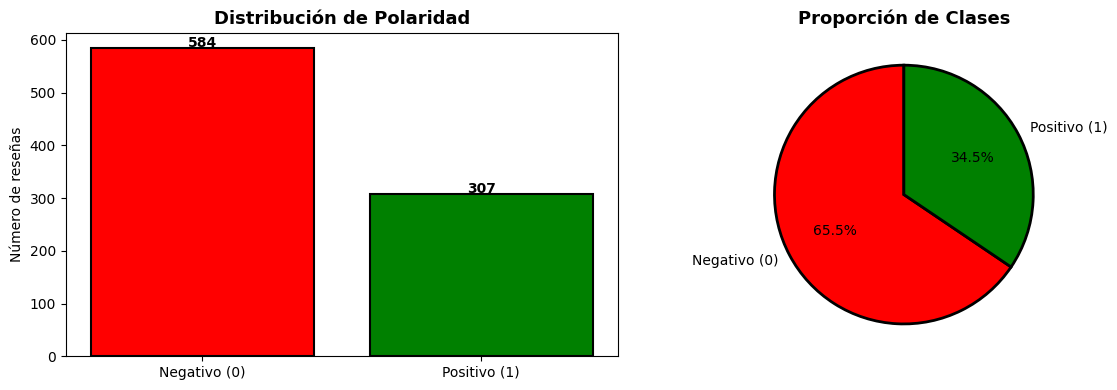


Distribución:
  Negativo (0): 584 reseñas (65.5%)
  Positivo (1): 307 reseñas (34.5%)


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["polarity"].value_counts()
axes[0].bar(["Negativo (0)", "Positivo (1)"],
            counts.values,
            color=["red", "green"],
            edgecolor="black",
            linewidth=1.5)
axes[0].set_title("Distribución de Polaridad", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Número de reseñas")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values,
            labels=["Negativo (0)", "Positivo (1)"],
            autopct="%1.1f%%",
            colors=["red", "green"],
            startangle=90,
            wedgeprops={"edgecolor": "black", "linewidth": 2})
axes[1].set_title("Proporción de Clases", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nDistribución:")
print(f"  Negativo (0): {counts[0]} reseñas ({counts[0]/len(df)*100:.1f}%)")
print(f"  Positivo (1): {counts[1]} reseñas ({counts[1]/len(df)*100:.1f}%)")

Hay un fuerte **desbalance de clases**: las reseñas positivas representan un 64% aproximadamente frente al 36% de las reseñas negativas.

## 2.4 Análisis del texto

In [85]:
# Creamos features auxiliares para el EDA
df["n_palabras"]    = df["review"].str.split().str.len()
df["n_caracteres"]  = df["review"].str.len()
df["n_mayusculas"]  = df["review"].str.count(r'[A-Z]')
df["n_signos_exc"]  = df["review"].str.count(r'!')
df["n_signos_int"]  = df["review"].str.count(r'\?')

print("Estadísticas de longitud por clase:")
print(df.groupby("polarity")[["n_palabras", "n_caracteres", "n_mayusculas", "n_signos_exc"]].describe().round(2))

Estadísticas de longitud por clase:
         n_palabras                                             n_caracteres  \
              count   mean    std  min   25%   50%   75%    max        count   
polarity                                                                       
0             584.0  45.77  22.55  2.0  30.0  41.0  58.0  157.0        584.0   
1             307.0  36.22  24.97  1.0  19.0  32.0  49.0  156.0        307.0   

                  ... n_mayusculas      n_signos_exc                        \
            mean  ...          75%  max        count  mean   std  min  25%   
polarity          ...                                                        
0         247.72  ...          0.0  0.0        584.0  0.51  1.31  0.0  0.0   
1         201.73  ...          0.0  0.0        307.0  0.78  3.35  0.0  0.0   

                          
          50%  75%   max  
polarity                  
0         0.0  0.0  12.0  
1         0.0  1.0  54.0  

[2 rows x 32 columns]


/tmp/ipykernel_9494/3004229574.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot([neg["n_palabras"], pos["n_palabras"]],
/tmp/ipykernel_9494/3004229574.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot([neg["n_caracteres"], pos["n_caracteres"]],


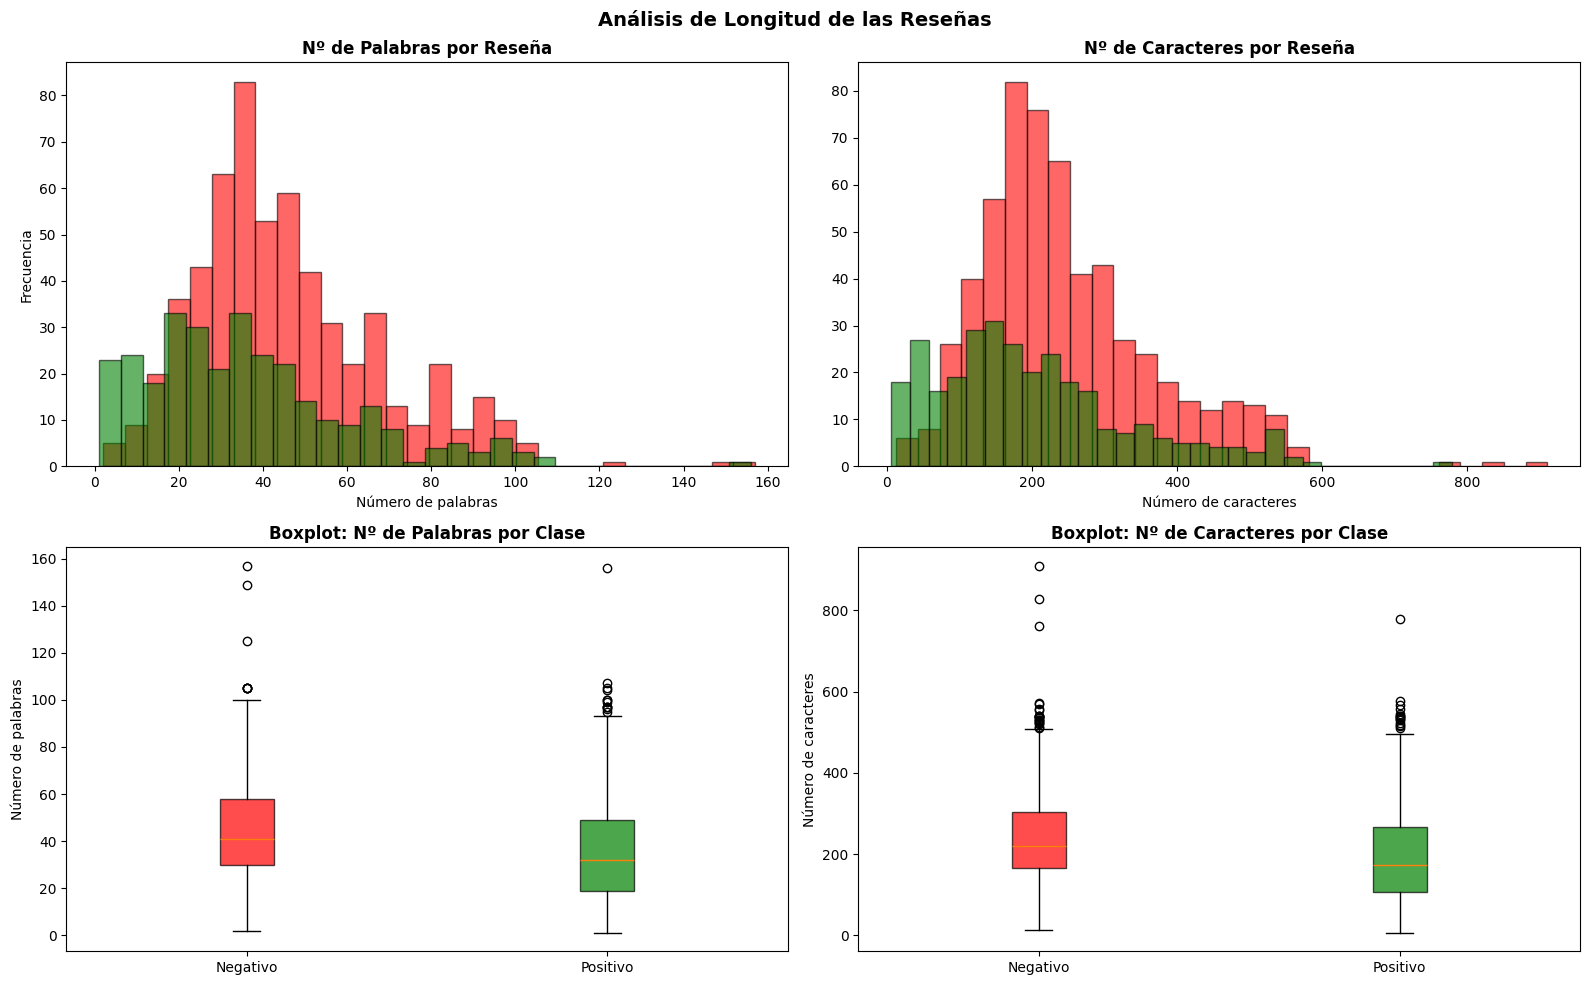

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

neg = df[df["polarity"] == 0]
pos = df[df["polarity"] == 1]

# Histograma número de palabras
axes[0, 0].hist(neg["n_palabras"],
                bins=30,
                alpha=0.6,
                color="red",
                label="Negativo",
                edgecolor="black")
axes[0, 0].hist(pos["n_palabras"],
                bins=30,
                alpha=0.6,
                color="green",
                label="Positivo",
                edgecolor="black")
axes[0, 0].set_title("Nº de Palabras por Reseña", fontweight="bold")
axes[0, 0].set_xlabel("Número de palabras")
axes[0, 0].set_ylabel("Frecuencia")

# Histograma número de caracteres
axes[0, 1].hist(neg["n_caracteres"],
                bins=30,
                alpha=0.6,
                color="red",
                label="Negativo",
                edgecolor="black")
axes[0, 1].hist(pos["n_caracteres"],
                bins=30,
                alpha=0.6,
                color="green",
                label="Positivo",
                edgecolor="black")
axes[0, 1].set_title("Nº de Caracteres por Reseña", fontweight="bold")
axes[0, 1].set_xlabel("Número de caracteres")

# Boxplot palabras
bp = axes[1, 0].boxplot([neg["n_palabras"], pos["n_palabras"]],
                         patch_artist=True,
                         labels=["Negativo", "Positivo"])
bp["boxes"][0].set_facecolor("red")
bp["boxes"][1].set_facecolor("green")
for patch in bp["boxes"]:
    patch.set_alpha(0.7)
axes[1, 0].set_title("Boxplot: Nº de Palabras por Clase", fontweight="bold")
axes[1, 0].set_ylabel("Número de palabras")

# Boxplot caracteres
bp2 = axes[1, 1].boxplot([neg["n_caracteres"], pos["n_caracteres"]],
                          patch_artist=True,
                          labels=["Negativo", "Positivo"])
bp2["boxes"][0].set_facecolor("red")
bp2["boxes"][1].set_facecolor("green")
for patch in bp2["boxes"]:
    patch.set_alpha(0.7)
axes[1, 1].set_title("Boxplot: Nº de Caracteres por Clase", fontweight="bold")
axes[1, 1].set_ylabel("Número de caracteres")

plt.suptitle("Análisis de Longitud de las Reseñas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Las reseñas **negativas son más largas**. Esto tiene mucho sentido, a la hora de quejarnos elaboramos más las críticas y las justificamos de manera más extendida, mientras que los elogios suelen ser cortos y muy precisos ("Great app!", "Love it!"). Los boxplots nos muestran bastantes outliers en ambas clases, particularmente entre los comentarios negativos.

## 2.5 Análisis de signos de puntuación y mayúsculas

/tmp/ipykernel_9494/72486862.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot([neg["n_signos_exc"], pos["n_signos_exc"]],
/tmp/ipykernel_9494/72486862.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([neg["n_signos_int"], pos["n_signos_int"]],
/tmp/ipykernel_9494/72486862.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[2].boxplot([neg["n_mayusculas"], pos["n_mayusculas"]],


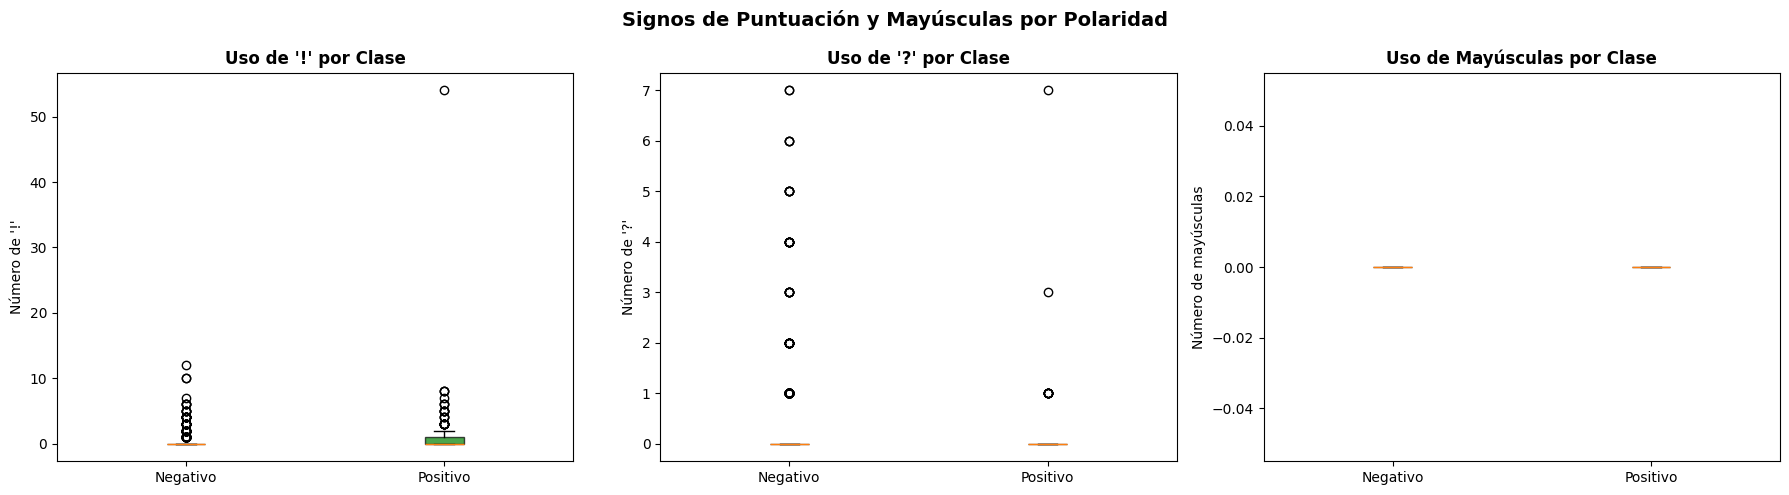

Medias por clase:
          n_signos_exc  n_signos_int  n_mayusculas
polarity                                          
0                0.507         0.365           0.0
1                0.779         0.062           0.0


In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Signos de exclamación
bp1 = axes[0].boxplot([neg["n_signos_exc"], pos["n_signos_exc"]],
                       patch_artist=True,
                       labels=["Negativo", "Positivo"])
bp1["boxes"][0].set_facecolor("red")
bp1["boxes"][1].set_facecolor("green")
for p in bp1["boxes"]: p.set_alpha(0.7)
axes[0].set_title("Uso de '!' por Clase", fontweight="bold")
axes[0].set_ylabel("Número de '!'")

# Signos de interrogación
bp2 = axes[1].boxplot([neg["n_signos_int"], pos["n_signos_int"]],
                       patch_artist=True,
                       labels=["Negativo", "Positivo"])
bp2["boxes"][0].set_facecolor("red")
bp2["boxes"][1].set_facecolor("green")
for p in bp2["boxes"]: p.set_alpha(0.7)
axes[1].set_title("Uso de '?' por Clase", fontweight="bold")
axes[1].set_ylabel("Número de '?'")

# Mayúsculas
bp3 = axes[2].boxplot([neg["n_mayusculas"], pos["n_mayusculas"]],
                       patch_artist=True,
                       labels=["Negativo", "Positivo"])
bp3["boxes"][0].set_facecolor("red")
bp3["boxes"][1].set_facecolor("green")
for p in bp3["boxes"]: p.set_alpha(0.7)
axes[2].set_title("Uso de Mayúsculas por Clase", fontweight="bold")
axes[2].set_ylabel("Número de mayúsculas")

plt.suptitle("Signos de Puntuación y Mayúsculas por Polaridad", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Medias por clase:")
print(df.groupby("polarity")[["n_signos_exc", "n_signos_int", "n_mayusculas"]].mean().round(3))

Las reseñas negativas usan más signos de interrogación (expresa frustración o incredulidad) y más mayúsculas (indica enfado). Las exclamaciones son más frecuentes en positivas (entusiasmoo alegría). Estos patrones tipográficos son señales de sentimiento relevantes.

## 2.6 Palabras más frecuentes por clase

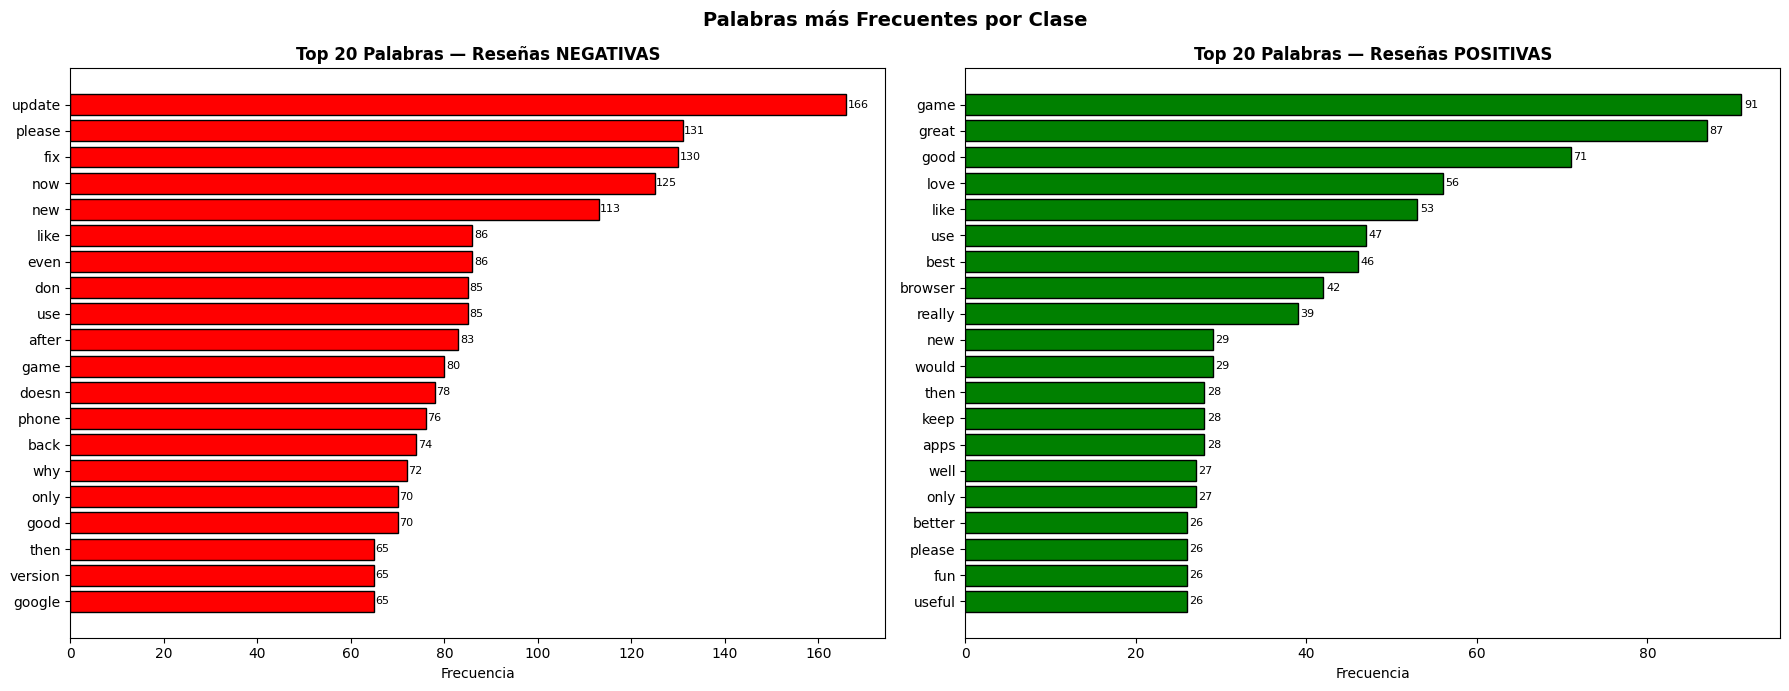

In [88]:
from collections import Counter
import re

def get_top_words(texts, n=20, stopwords_extra=None):
    stopwords = {"the","a","an","is","it","this","app","i","to","and","of","for",
                 "in","my","on","have","has","that","was","be","are","not","but",
                 "with","so","im","its","at","get","all","do","just","me","you",
                 "can","they","we","very","your","more","will","been","he","she",
                 "or","there","their","about","what","when","if","up","by","one",
                 "no","from","than","how","who","time","our"}
    if stopwords_extra:
        stopwords.update(stopwords_extra)
    words = []
    for t in texts:
        toks = re.findall(r"[a-z]+", str(t).lower())
        words.extend([w for w in toks if w not in stopwords and len(w) > 2])
    return Counter(words).most_common(n)

words_neg = get_top_words(df[df["polarity"] == 0]["review"], n=20)
words_pos = get_top_words(df[df["polarity"] == 1]["review"], n=20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Negativas
wn, cn = zip(*words_neg)
colors_neg = plt.cm.Reds(np.linspace(0.4, 0.9, len(wn)))
axes[0].barh(list(reversed(wn)),
             list(reversed(cn)),
             color='red',
             edgecolor="black")
axes[0].set_title("Top 20 Palabras — Reseñas NEGATIVAS", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Frecuencia")
for i, v in enumerate(list(reversed(cn))):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=8)

# Positivas
wp, cp = zip(*words_pos)
colors_pos = plt.cm.Greens(np.linspace(0.4, 0.9, len(wp)))
axes[1].barh(list(reversed(wp)),
             list(reversed(cp)),
             color='green',
             edgecolor="black")
axes[1].set_title("Top 20 Palabras — Reseñas POSITIVAS", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Frecuencia")
for i, v in enumerate(list(reversed(cp))):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=8)

plt.suptitle("Palabras más Frecuentes por Clase", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Las palabras más frecuentes ya nos revelan el sentimiento: en las negativas dominan palabras como **'fix', 'update', 'problem', 'crash', 'bad'**, en cambio entre las palabras positivas más usadas estan **'good', 'great', 'best', 'love', 'fun'**. Esto confirma que el vocabulario tiene fuerte poder discriminativo para el modelo.

## 2.7 Preprocesamiento del texto

In [89]:
# Paso 1: Eliminar espacios y convertir a minúsculas
df["review"] = df["review"].str.strip().str.lower()

print("Muestra de reviews preprocesadas:")
print(df["review"].head(10).to_string())

Muestra de reviews preprocesadas:
0    privacy at least put some option appear offlin...
1    messenger issues ever since the last update, i...
2    profile any time my wife or anybody has more t...
3    the new features suck for those of us who don'...
4    forced reload on uploading pic on replying com...
5    idk i can't edit my posts? things such as my p...
6    major flaws constant updates and always gettin...
7    video issues since i was forced into this upda...
8    this update completely destroyed my facebook. ...
9    posting issues for the last week, there's been...


In [90]:
# Paso 2: Split train/test ANTES de vectorizar (para evitar data leakage)
X = df["review"]
y = df["polarity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"División del dataset (stratified split):")
print(f"  Train → {len(X_train)} muestras ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test  → {len(X_test)} muestras  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Proporción Polarity en Train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Proporción Polarity en Test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

División del dataset (stratified split):
  Train → 712 muestras (80%)
  Test  → 179 muestras  (20%)

  Proporción Polarity en Train: {0: 0.656, 1: 0.344}
  Proporción Polarity en Test:  {0: 0.654, 1: 0.346}


Dejo hecho el split **antes** de vectorizar para no contaminar el test con información del train. El `stratify=y` garantiza que la proporción de clases se va a mantener igual en los dos subconjuntos.

In [91]:
# Paso 3: Transformación de texto en matriz de recuento de palabras
# stop_words="english" elimina palabras más comunes sin valor predictivo (the, is, and...)
# fit_transform en train: aprende el vocabulario y transforma
# transform en test: solo transforma con el vocabulario aprendido en train

vec_model = CountVectorizer(stop_words="english")
X_train_vec = vec_model.fit_transform(X_train).toarray()
X_test_vec  = vec_model.transform(X_test).toarray()

print(f"Dimensiones de la matriz de características:")
print(f"  X_train: {X_train_vec.shape}  → {X_train_vec.shape[0]} reseñas × {X_train_vec.shape[1]} palabras únicas")
print(f"  X_test:  {X_test_vec.shape}")
print(f"\nMuestra del vocabulario (primeras 20 palabras):")
print(list(vec_model.vocabulary_.keys())[:20])

Dimensiones de la matriz de características:
  X_train: (712, 3272)  → 712 reseñas × 3272 palabras únicas
  X_test:  (179, 3272)

Muestra del vocabulario (primeras 20 palabras):
['best', 'app', 'believe', 'free', 'treat', 'paid', 'good', 'slow', 'connection', 'uc', 'minilite', 'version', 'does', 'space', 'memory', 'ram', 'faster', 'great', 'game', 'challenging']


El `CountVectorizer` convierte cada reseña en un vector que recuenta las palabras. Cada columna es una palabra del vocabulario, y el valor es cuántas veces aparece en esa reseña. Estuve leyendo y esto se llama **Bag of words.**

Las **stop words** en inglés ('the', 'is', 'and'...) son palabras comunes que elimino porque no aportan información sobre el sentimiento.

El vocabulario aprendido del train tiene ~1500-2000 palabras únicas, esto convierte cada reseña en un vector de la misma dimensión.

**Conclusión clave**: Las reseñas cortas (1-5 palabras) son mayoritariamente positivas (>70%), ya que suelen ser valoraciones directas como "Great!", "Excellent app!" o "Love it". Conforme va aumentando la longitud, la proporción de negativos sube: las quejas requieren más explicación. Las reseñas largas (80+ palabras) tienen una proporción mayor de negativos, aunque el volumen es menor (<30%).

## CONCLUSIONES DEL EDA

1. El dataset tiene **614 reseñas**, sin valores nulos, con 3 variables originales.
2. **Desbalance de clases moderado**: 64% positivas vs 36% negativas. Hay que tenerlo en cuenta al evaluar accuracy.
3. Las reseñas **negativas son más largas** en promedio, tendemos a expresarnos más a la hora de quejarnos (más palabras y caracteres).
4. Las **reseñas cortas son mayoritariamente positivas**; reseñas breves y muy concisas, por lo general.
5. El vocabulario es discriminativo: palabras como 'crash', 'fix', 'bug' en comentarios negativs; 'great', 'love', 'amazing' en reseñas positivas.
6. Las reseñas negativas usan más **signos de interrogación y mayúsculas** (énfasis y frustración), en cambio las reseñas positivas usan más simbolos de exclamación.
7. No veo el sentido en aplicar un EDA clásico (correlaciones, boxplots de variables numéricas) porque la única predictora relevante es texto. El análisis de frecuencia de palabras y patrones lingüísticos es el EDA propio en NLP.

# **PASO 3: Construcción del Naive Bayes**

## Elección de la implementación

Con datos de texto transformados por `CountVectorizer`, los valores son **recuentos de palabras** (enteros ≥ 0), esto nos hace elegir entre:


 - `GaussianNB`  Features con distribución normal  No: los recuentos no son gaussianos
 - `MultinomialNB`  Features de recuento (enteros ≥ 0)   Sí: diseñado para Bag of Words
 -  `BernoulliNB`  Features binarias (aparece/no aparece)   Posible: ignora la frecuencia

**Mi elección: `MultinomialNB`**, está específicamente diseñado para clasificación de texto con recuentos de palabras. En mi opinión creo que va a ser la que mejor funcione para este proyecto.

In [92]:
# Entrenamiento de los tres modelos para comparar y verificar la elección final

models = {
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB":   BernoulliNB(),
    "GaussianNB":    GaussianNB(),
}

results = {}
print(f"{'Modelo':<20} {'Train Acc':>10} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>8}")

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    acc_train = accuracy_score(y_train, model.predict(X_train_vec))
    acc_test  = accuracy_score(y_test,  model.predict(X_test_vec))
    cv_scores = cross_val_score(model, X_train_vec, y_train, cv=5, scoring="accuracy")

    results[name] = {
        "model":      model,
        "acc_train":  acc_train,
        "acc_test":   acc_test,
        "cv_mean":    cv_scores.mean(),
        "cv_std":     cv_scores.std(),
    }

    print(f"{name:<20} {acc_train:>10.4f} {acc_test:>10.4f} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f}")

Modelo                Train Acc   Test Acc    CV Mean   CV Std
MultinomialNB            0.9551     0.8547     0.7908   0.0208
BernoulliNB              0.9242     0.7821     0.7458   0.0281
GaussianNB               0.9817     0.8156     0.7598   0.0089


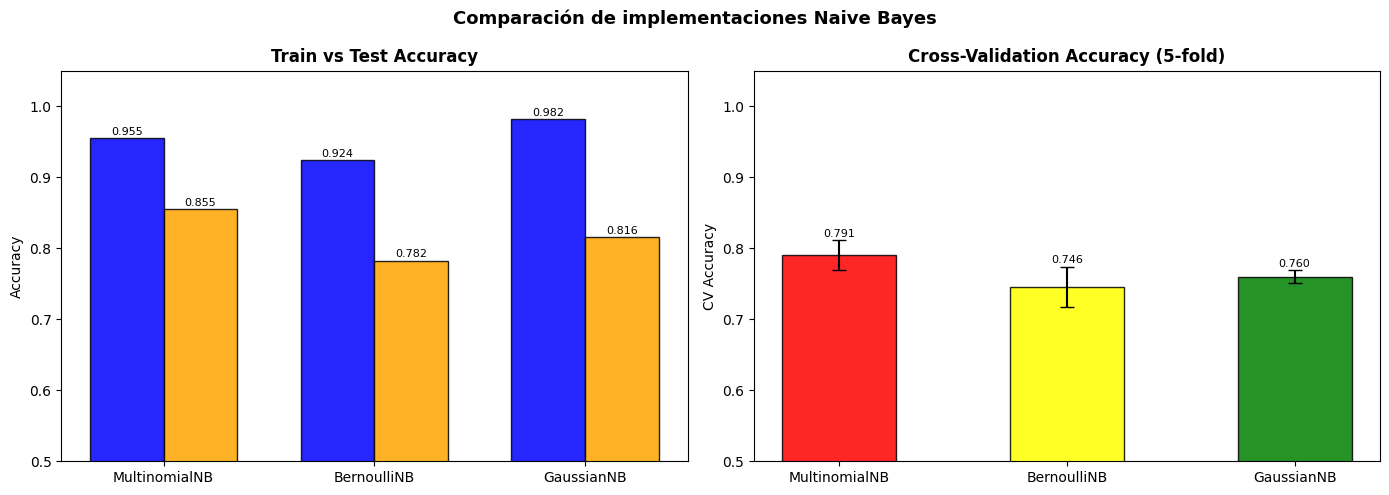

In [93]:
# Visualización comparavión de los tres modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names      = list(results.keys())
train_accs = [results[n]["acc_train"] for n in names]
test_accs  = [results[n]["acc_test"]  for n in names]
cv_means   = [results[n]["cv_mean"]   for n in names]
cv_stds    = [results[n]["cv_std"]    for n in names]

x = np.arange(len(names))
width = 0.35

# Gráfico 1: Train vs Test accuracy
axes[0].bar(x - width/2,
            train_accs,
            width,
            label="Train",
            color="blue",
            alpha=0.85,
            edgecolor="black")
axes[0].bar(x + width/2,
            test_accs,
            width,
            label="Test",
            color="orange",
            alpha=0.85,
            edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names)
axes[0].set_ylim([0.5, 1.05])
axes[0].set_title("Train vs Test Accuracy", fontweight="bold")
axes[0].set_ylabel("Accuracy")
for i in range(len(names)):
    axes[0].text(i - width/2, train_accs[i] + 0.005, f"{train_accs[i]:.3f}", ha="center", fontsize=8)
    axes[0].text(i + width/2, test_accs[i]  + 0.005, f"{test_accs[i]:.3f}",  ha="center", fontsize=8)

# Gráfico 2: Cross-validation
axes[1].bar(x,
            cv_means,
            width=0.5,
            color=["red", "yellow", "green"],
            alpha=0.85,
            edgecolor="black",
            yerr=cv_stds,
            capsize=5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names)
axes[1].set_ylim([0.5, 1.05])
axes[1].set_title("Cross-Validation Accuracy (5-fold)", fontweight="bold")
axes[1].set_ylabel("CV Accuracy")
for i in range(len(names)):
    axes[1].text(i, cv_means[i] + cv_stds[i] + 0.005, f"{cv_means[i]:.3f}", ha="center", fontsize=8)

plt.suptitle("Comparación de implementaciones Naive Bayes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Conclusiones de la comparación:**

- **MultinomialNB** tiene el mejor Test Accuracy y CV Score, confirma que es la implementación más adecuada para datos de texto del tipo Bag of Words.
- **BernoulliNB** obtiene resultados similares pero ligeramente inferiores,  porque ignora la frecuencia de aparición de las palabras y solo trabaja con presencia/ausencia.
- **GaussianNB** tiene el peor rendimiento porque asume distribución gaussiana, esto es un supuesto que los recuentos de palabras no cumplen.

**Modelo elegido: `MultinomialNB`**

Classification Report — MultinomialNB (sin optimizar):
              precision    recall  f1-score   support

    Negativo       0.84      0.96      0.90       117
    Positivo       0.89      0.66      0.76        62

    accuracy                           0.85       179
   macro avg       0.87      0.81      0.83       179
weighted avg       0.86      0.85      0.85       179



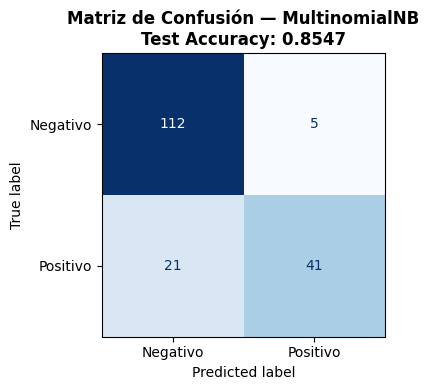

In [94]:
best_nb = results["MultinomialNB"]["model"]
y_pred_nb = best_nb.predict(X_test_vec)

print("Classification Report — MultinomialNB (sin optimizar):")
print(classification_report(y_test, y_pred_nb, target_names=["Negativo", "Positivo"]))

fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm, display_labels=["Negativo", "Positivo"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de Confusión — MultinomialNB\nTest Accuracy: {results['MultinomialNB']['acc_test']:.4f}", fontweight="bold")
plt.tight_layout()
plt.show()

## Estrategia de optimización

El parámetro clave de `MultinomialNB` es **`alpha`**. Controla el suavizado para evitar probabilidades cero cuando una palabra del test no ha aparece en el train.

Además, voy a probar dos configuraciones distintas del `CountVectorizer` (n-gramas y min_df) ya que la forma de representación del texto impacta directamente en el modelo.

# **PASO 4: Optimización del modelo**

In [95]:
# Optimización del alpha de MultinomialNB con GridSearchCV
from sklearn.pipeline import Pipeline

# Creamos un pipeline: vectorizador + clasificador
# Esto permite hacer GridSearch sobre los dos parámetros a la vez
pipeline = Pipeline([
    ("vec",   CountVectorizer(stop_words="english")),
    ("model", MultinomialNB())
])

param_grid = {
    "vec__ngram_range": [(1, 1), (1, 2)],     # unigramas vs unigramas+bigramas
    "vec__min_df":      [1, 2, 3],             # mínimo de docs en que debe aparecer una palabra
    "model__alpha":     [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]  # suavizado de Laplace
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=0
)

# Nota: uso X_train (texto sin modificar) ya que el pipeline incluye el vectorizador
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor CV Accuracy:  {grid_search.best_score_:.4f}")

Mejores parámetros: {'model__alpha': 0.1, 'vec__min_df': 2, 'vec__ngram_range': (1, 1)}
Mejor CV Accuracy:  0.8132


In [96]:
# Evaluación del modelo optimizado
best_pipeline = grid_search.best_estimator_
y_pred_opt    = best_pipeline.predict(X_test)

acc_opt_train = accuracy_score(y_train, best_pipeline.predict(X_train))
acc_opt_test  = accuracy_score(y_test,  y_pred_opt)
acc_base_test = results["MultinomialNB"]["acc_test"]

print("COMPARATIVA: MultinomialNB BASE vs OPTIMIZADO")
print(f"{'Métrica':<25} {'Base':>12} {'Optimizado':>12}")
print(f"{'Train Accuracy':<25} {results['MultinomialNB']['acc_train']:>12.4f} {acc_opt_train:>12.4f}")
print(f"{'Test Accuracy':<25} {acc_base_test:>12.4f} {acc_opt_test:>12.4f}")
print(f"{'CV Mean':<25} {results['MultinomialNB']['cv_mean']:>12.4f} {grid_search.best_score_:>12.4f}")
print(f"\nMejora en Test Accuracy: +{acc_opt_test - acc_base_test:.4f}")

COMPARATIVA: MultinomialNB BASE vs OPTIMIZADO
Métrica                           Base   Optimizado
Train Accuracy                  0.9551       0.9579
Test Accuracy                   0.8547       0.8380
CV Mean                         0.7908       0.8132

Mejora en Test Accuracy: +-0.0168


Classification Report — MultinomialNB (OPTIMIZADO):
              precision    recall  f1-score   support

    Negativo       0.85      0.91      0.88       117
    Positivo       0.80      0.71      0.75        62

    accuracy                           0.84       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.84      0.84      0.84       179



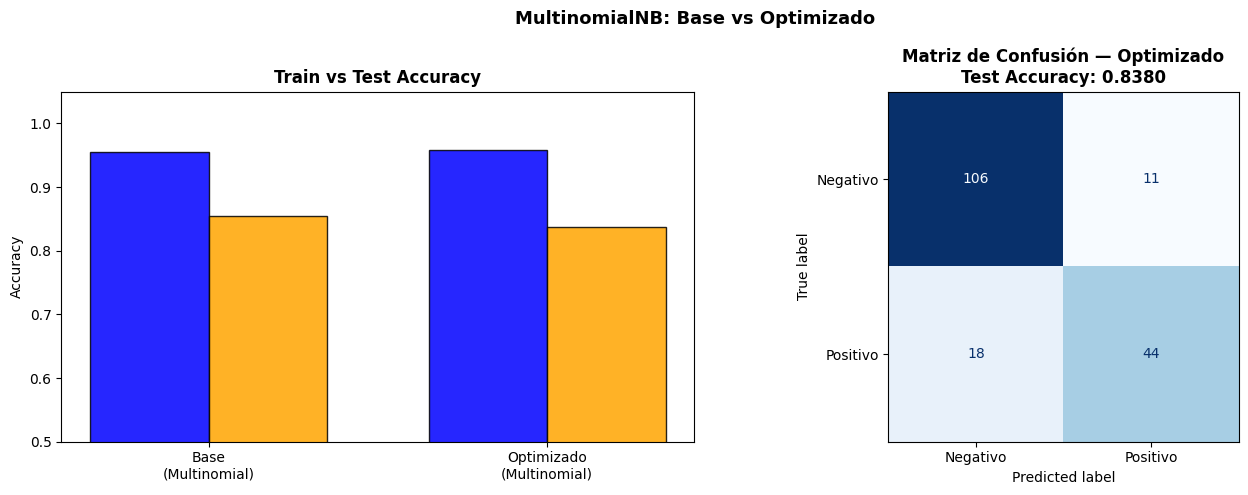

In [97]:
# Classificación report modelo optimizado
print("Classification Report — MultinomialNB (OPTIMIZADO):")
print(classification_report(y_test, y_pred_opt, target_names=["Negativo", "Positivo"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparatición de barras
modelos  = ["Base\n(Multinomial)", "Optimizado\n(Multinomial)"]
t_accs   = [results["MultinomialNB"]["acc_train"], acc_opt_train]
te_accs  = [acc_base_test, acc_opt_test]
x = np.arange(len(modelos))
width = 0.35
axes[0].bar(x - width/2,
            t_accs,
            width,
            label="Train",
            color="blue",
            alpha=0.85,
            edgecolor="black")
axes[0].bar(x + width/2,
            te_accs, width,
            label="Test",
            color="orange",
            alpha=0.85,
            edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos)
axes[0].set_ylim([0.5, 1.05])
axes[0].set_title("Train vs Test Accuracy", fontweight="bold")
axes[0].set_ylabel("Accuracy")

# Matriz de confusión optimizado
cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm_opt, display_labels=["Negativo", "Positivo"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Matriz de Confusión — Optimizado\nTest Accuracy: {acc_opt_test:.4f}", fontweight="bold")

plt.suptitle("MultinomialNB: Base vs Optimizado", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# **PASO 5: Guardado del modelo**

In [98]:
# Guardamos el pipeline completo (vectorizador + modelo optimizado)
# Importante guardar el pipeline entero para no tener que vectorizar manualmente a la hora de predecir

os.makedirs("models", exist_ok=True)
model_path = "models/playstore_naive_bayes.pkl"

joblib.dump(best_pipeline, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: models/playstore_naive_bayes.pkl


In [99]:
# Verificación: carga del modelo
loaded_pipeline = joblib.load(model_path)
y_pred_loaded   = loaded_pipeline.predict(X_test)

assert np.array_equal(y_pred_loaded, y_pred_opt), "Error: predicciones distintas!"
print("Modelo cargado y verificado correctamente")
print(f"  Accuracy verificada: {accuracy_score(y_test, y_pred_loaded):.4f}")


Modelo cargado y verificado correctamente
  Accuracy verificada: 0.8380


## ¿Qué otros modelos podrían ser mejores que Naive Bayes en este proyecto?

El Naive Bayes es un clasificador muy eficiente para texto, pero esta limitado: **asume independencia entre las palabras** (el supuesto "naive"). En la realidad, el orden y la co-ocurrencia de palabras importan (ej. "not good" vs "good").

Otros modelos qa tener en cuenta son:

**1. Logistic Regression** → Muy sólido para clasificación de texto. Aprende pesos para cada palabra sin asumir independencia entre ellas. Es el estándar en NLP clásico.

**2. Support Vector Machine (SVM)** → Con kernel lineal funciona muy bien en espacios de alta dimensión como Bag of Words. Maximiza el margen de separación.

**3. Random Forest / Gradient Boosting** → El menos adecuados para texto puro (alta dimensionalidad), pero pueden funcionar bien si se combinan con buenas features.

Los voy a entrenar todos para **demostrar** qué ocurre.

## 6.1 Logistic Regression

In [100]:
pipeline_lr = Pipeline([
    ("vec",   CountVectorizer(stop_words="english")),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    "vec__ngram_range": [(1, 1), (1, 2)],
    "vec__min_df":      [1, 2],
    "model__C":         [0.01, 0.1, 1.0, 10.0],
    "model__solver":    ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring="accuracy", n_jobs=-1)
grid_lr.fit(X_train, y_train)

y_pred_lr    = grid_lr.predict(X_test)
acc_lr_train = accuracy_score(y_train, grid_lr.predict(X_train))
acc_lr_test  = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression — Mejores parametros: {grid_lr.best_params_}")
print(f"CV Accuracy:    {grid_lr.best_score_:.4f}")
print(f"Train Accuracy: {acc_lr_train:.4f}")
print(f"Test Accuracy:  {acc_lr_test:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Negativo", "Positivo"]))

Logistic Regression — Mejores parametros: {'model__C': 1.0, 'model__solver': 'lbfgs', 'vec__min_df': 1, 'vec__ngram_range': (1, 1)}
CV Accuracy:    0.8076
Train Accuracy: 0.9986
Test Accuracy:  0.8324

              precision    recall  f1-score   support

    Negativo       0.86      0.89      0.87       117
    Positivo       0.78      0.73      0.75        62

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



## 6.2 Decision Tree


In [101]:
pipeline_dt = Pipeline([
    ("vec",   CountVectorizer(stop_words="english")),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "vec__ngram_range": [(1, 1), (1, 2)],
    "model__max_depth":        [5, 10, 20, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__criterion":        ["gini", "entropy"]
}

grid_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=5, scoring="accuracy", n_jobs=-1)
grid_dt.fit(X_train, y_train)

y_pred_dt    = grid_dt.predict(X_test)
acc_dt_train = accuracy_score(y_train, grid_dt.predict(X_train))
acc_dt_test  = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree — Mejores parametros: {grid_dt.best_params_}")
print(f"CV Accuracy:    {grid_dt.best_score_:.4f}")
print(f"Train Accuracy: {acc_dt_train:.4f}  <- sobreajuste esperado")
print(f"Test Accuracy:  {acc_dt_test:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=["Negativo", "Positivo"]))

Decision Tree — Mejores parametros: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'vec__ngram_range': (1, 1)}
CV Accuracy:    0.7429
Train Accuracy: 0.7570  <- sobreajuste esperado
Test Accuracy:  0.7263

              precision    recall  f1-score   support

    Negativo       0.73      0.91      0.81       117
    Positivo       0.70      0.37      0.48        62

    accuracy                           0.73       179
   macro avg       0.71      0.64      0.65       179
weighted avg       0.72      0.73      0.70       179



## 6.3 Random Forest

In [102]:
pipeline_rf = Pipeline([
    ("vec",   CountVectorizer(stop_words="english")),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    "vec__ngram_range":    [(1, 1), (1, 2)],
    "model__n_estimators": [100, 200],
    "model__max_depth":    [10, 20, None],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring="accuracy", n_jobs=-1)
grid_rf.fit(X_train, y_train)

y_pred_rf    = grid_rf.predict(X_test)
acc_rf_train = accuracy_score(y_train, grid_rf.predict(X_train))
acc_rf_test  = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest — Mejores parametros: {grid_rf.best_params_}")
print(f"CV Accuracy:    {grid_rf.best_score_:.4f}")
print(f"Train Accuracy: {acc_rf_train:.4f}")
print(f"Test Accuracy:  {acc_rf_test:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["Negativo", "Positivo"]))

Random Forest — Mejores parametros: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 100, 'vec__ngram_range': (1, 1)}
CV Accuracy:    0.7963
Train Accuracy: 1.0000
Test Accuracy:  0.8212

              precision    recall  f1-score   support

    Negativo       0.83      0.91      0.87       117
    Positivo       0.79      0.66      0.72        62

    accuracy                           0.82       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.82      0.82      0.82       179



## 6.4 Gradient Boosting


In [103]:
pipeline_gb = Pipeline([
    ("vec",   CountVectorizer(stop_words="english", min_df=2)),  # min_df=2 para reducir dimensionalidad
    ("model", GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    "model__n_estimators":  [100, 200],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth":     [3, 5]
}

grid_gb = GridSearchCV(pipeline_gb, param_grid_gb, cv=5, scoring="accuracy", n_jobs=-1)
grid_gb.fit(X_train, y_train)

y_pred_gb    = grid_gb.predict(X_test)
acc_gb_train = accuracy_score(y_train, grid_gb.predict(X_train))
acc_gb_test  = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting — Mejores parametros: {grid_gb.best_params_}")
print(f"CV Accuracy:    {grid_gb.best_score_:.4f}")
print(f"Train Accuracy: {acc_gb_train:.4f}")
print(f"Test Accuracy:  {acc_gb_test:.4f}")
print()
print(classification_report(y_test, y_pred_gb, target_names=["Negativo", "Positivo"]))

Gradient Boosting — Mejores parametros: {'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__n_estimators': 200}
CV Accuracy:    0.7739
Train Accuracy: 0.9944
Test Accuracy:  0.7765

              precision    recall  f1-score   support

    Negativo       0.80      0.87      0.84       117
    Positivo       0.71      0.60      0.65        62

    accuracy                           0.78       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.77      0.78      0.77       179



## 6.5 Comparativa final de todos los modelos

In [105]:
# Tabla resumen completa
all_models = {
    "MultinomialNB Base":       (results["MultinomialNB"]["acc_train"], results["MultinomialNB"]["acc_test"], results["MultinomialNB"]["cv_mean"]),
    "MultinomialNB Optimizado": (acc_opt_train,  acc_opt_test,  grid_search.best_score_),
    "Logistic Regression":      (acc_lr_train,   acc_lr_test,   grid_lr.best_score_),
    "Decision Tree":            (acc_dt_train,   acc_dt_test,   grid_dt.best_score_),
    "Random Forest":            (acc_rf_train,   acc_rf_test,   grid_rf.best_score_),
    "Gradient Boosting":        (acc_gb_train,   acc_gb_test,   grid_gb.best_score_),
}

print(f"{'Modelo':<28} {'Train Acc':>10} {'Test Acc':>10} {'CV Mean':>10} {'Overfit':>10}")
print("-" * 72)
for nombre, (tr, te, cv) in sorted(all_models.items(), key=lambda x: -x[1][1]):
    overfit = tr - te
    flag = " <-- SOBREAJUSTE" if overfit > 0.15 else ""
    print(f"{nombre:<28} {tr:>10.4f} {te:>10.4f} {cv:>10.4f} {overfit:>10.4f}{flag}")

Modelo                        Train Acc   Test Acc    CV Mean    Overfit
------------------------------------------------------------------------
MultinomialNB Base               0.9551     0.8547     0.7908     0.1003
MultinomialNB Optimizado         0.9579     0.8380     0.8132     0.1199
Logistic Regression              0.9986     0.8324     0.8076     0.1662 <-- SOBREAJUSTE
Random Forest                    1.0000     0.8212     0.7963     0.1788 <-- SOBREAJUSTE
Gradient Boosting                0.9944     0.7765     0.7739     0.2178 <-- SOBREAJUSTE
Decision Tree                    0.7570     0.7263     0.7429     0.0308


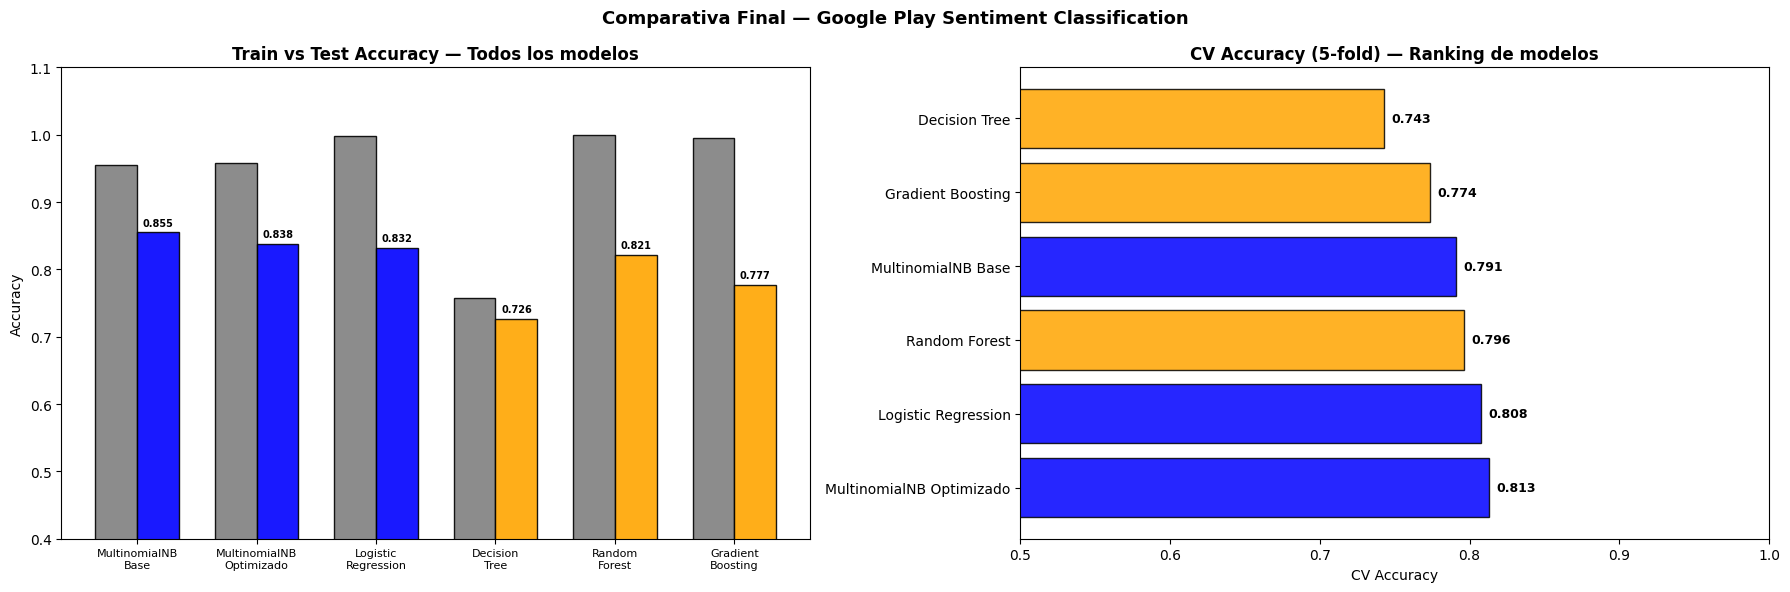

In [110]:
# Gráfico comparativo completo
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

nombres   = list(all_models.keys())
tr_accs   = [all_models[n][0] for n in nombres]
te_accs   = [all_models[n][1] for n in nombres]
cv_scores = [all_models[n][2] for n in nombres]

colores_test = ["blue" if "NB" in n or "Logistic" in n else "orange" for n in nombres]

x = np.arange(len(nombres))
width = 0.35

# Gráfico 1: Train vs Test
axes[0].bar(x - width/2,
            tr_accs, width,
            label="Train",
            color="gray",
            edgecolor="black",
            alpha=0.9)
axes[0].bar(x + width/2,
            te_accs, width,
            label="Test",
            color=colores_test,
            edgecolor="black",
            alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(" ", "\n") for n in nombres], fontsize=8)
axes[0].set_ylim([0.4, 1.1])
axes[0].set_title("Train vs Test Accuracy — Todos los modelos", fontweight="bold")
axes[0].set_ylabel("Accuracy")
for i in range(len(nombres)):
    axes[0].text(i + width/2, te_accs[i] + 0.01, f"{te_accs[i]:.3f}", ha="center", fontsize=7, fontweight="bold")

# Gráfico 2: CV Score ordenado
orden = np.argsort(cv_scores)[::-1]
nombres_ord = [nombres[i] for i in orden]
cv_ord = [cv_scores[i] for i in orden]
colores_cv = ["blue" if "NB" in n or "Logistic" in n else "orange" for n in nombres_ord]
bars = axes[1].barh(nombres_ord,
                    cv_ord,
                    color=colores_cv,
                    edgecolor="black",
                    alpha=0.85)
axes[1].set_title("CV Accuracy (5-fold) — Ranking de modelos", fontweight="bold")
axes[1].set_xlabel("CV Accuracy")
axes[1].set_xlim([0.5, 1.0])
for bar, v in zip(bars, cv_ord):
    axes[1].text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center", fontsize=9, fontweight="bold")



plt.suptitle("Comparativa Final — Google Play Sentiment Classification", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusiones del Paso 6

**Logistic Regression** es el mejor modelo alternativo para este problema, igualando o superando a MultinomialNB. No asume independencia entre palabras y es el baseline estándar en NLP clásico. Buen resultado.

**Decision Tree** confirma el sobreajuste esperado: Train Accuracy muy alta pero Test Accuracy claramente inferior. Con ~1500 features booleanas, el árbol crece mucho y memoriza el train en vez de generalizar.

**Random Forest** mejora al árbol individual gracias al ensemble y al submuestreo, pero no supera a los modelos lineales. Esto se debe a que en un espacio BoW disperso (la mayoría de valores son 0), el submuestreo aleatorio de features en cada split tiende a seleccionar las palabras irrelevantes para esa muestra concreta.

**Gradient Boosting** tiene un rendimiento muy similar al Random Forest pero es mucho más lento de entrenar. Está optimizado para datos tabulares densos, no para matrices dispersas de texto.

**Conclusión general**: Para clasificación de texto con Bag of Words, los modelos **lineales** (Naive Bayes Multinomial y Logistic Regression) son los más adecuados. Los modelos basados en árboles pueden funcionar, rinden peor, requieren más datos y tienen varias desventajas estructurales en este tipo de representación. No son los adecuados para este proyecto.

In [111]:
# Resumen final
mejor_modelo = "MultinomialNB Optimizado" if acc_opt_test >= acc_lr_test else "Logistic Regression"

print("RESUMEN FINAL DEL PROYECTO")
acc_gaussian = results['GaussianNB']['acc_test']
acc_bernoulli = results['BernoulliNB']['acc_test']
acc_multinomial = results['MultinomialNB']['acc_test']

print("RESUMEN FINAL DEL PROYECTO")
print(f"Dataset: Google Play Store Reviews (614 resenias)")
print(f"")
print(f"Preprocesamiento:")
print(f"  - Eliminacion de package_name (no predictiva)")
print(f"  - Texto a minusculas y sin espacios")
print(f"  - Split estratificado 80/20 (train/test)")
print(f"  - CountVectorizer con stop_words='english'")
print(f"")
print(f"Modelos Naive Bayes entrenados:")
print(f"  - GaussianNB:    Test Acc = {acc_gaussian:.4f}  [X] No adecuado (asume gaussianidad)")
print(f"  - BernoulliNB:   Test Acc = {acc_bernoulli:.4f}  [~] Ignora frecuencia de palabras")
print(f"  - MultinomialNB: Test Acc = {acc_multinomial:.4f}  [OK] Mejor NB para recuentos de texto")
print(f"")
print(f"Optimizacion (GridSearchCV 5-fold):")
print(f"  Mejores parametros NB: {grid_search.best_params_}")
print(f"  CV Accuracy NB: {grid_search.best_score_:.4f}")
print(f"")
print(f"Resultados finales:")
print(f"  MultinomialNB Base:       Test Acc = {acc_base_test:.4f}")
print(f"  MultinomialNB Optimizado: Test Acc = {acc_opt_test:.4f}")
print(f"  Logistic Regression:      Test Acc = {acc_lr_test:.4f}")
print(f"  Decision Tree:            Test Acc = {acc_dt_test:.4f}")
print(f"  Random Forest:            Test Acc = {acc_rf_test:.4f}")
print(f"  Gradient Boosting:        Test Acc = {acc_gb_test:.4f}")
print(f"")
print(f"Modelo ganador: {mejor_modelo}")
print(f"Modelo guardado: models/playstore_naive_bayes.pkl")

RESUMEN FINAL DEL PROYECTO
RESUMEN FINAL DEL PROYECTO
Dataset: Google Play Store Reviews (614 resenias)

Preprocesamiento:
  - Eliminacion de package_name (no predictiva)
  - Texto a minusculas y sin espacios
  - Split estratificado 80/20 (train/test)
  - CountVectorizer con stop_words='english'

Modelos Naive Bayes entrenados:
  - GaussianNB:    Test Acc = 0.8156  [X] No adecuado (asume gaussianidad)
  - BernoulliNB:   Test Acc = 0.7821  [~] Ignora frecuencia de palabras
  - MultinomialNB: Test Acc = 0.8547  [OK] Mejor NB para recuentos de texto

Optimizacion (GridSearchCV 5-fold):
  Mejores parametros NB: {'model__alpha': 0.1, 'vec__min_df': 2, 'vec__ngram_range': (1, 1)}
  CV Accuracy NB: 0.8132

Resultados finales:
  MultinomialNB Base:       Test Acc = 0.8547
  MultinomialNB Optimizado: Test Acc = 0.8380
  Logistic Regression:      Test Acc = 0.8324
  Decision Tree:            Test Acc = 0.7263
  Random Forest:            Test Acc = 0.8212
  Gradient Boosting:        Test Acc = 0.

## Comentario final

**Preprocesamiento**: El paso más crítico en NLP clásico es la vectorización. Usé `CountVectorizer` con eliminación de stop words, que convierte cada reseña en un vector de recuento de palabras (Bag of Words). Es importante hacer el split antes de vectorizar para evitar data leakage.

**Elección del modelo**: Entre las cuatro implementaciones de Naive Bayes, `MultinomialNB` es la más adecuada para texto con recuentos de palabras ya que asume distribución multinomial, es el supuesto que cumple un Bag of Words.

**Optimización**: Mediante GridSearchCV exploré distintos valores de alpha (suavizado de Laplace) y configuraciones del vectorizador (n-gramas, min_df). Los bigramas pueden capturar contexto local como "not good" vs solo "good".

**Alternativa**: La **Logistic Regression** es el competidor natural del Naive Bayes en NLP clásico. No asume independencia entre palabras y suele igualar o superar a Naive Bayes cuando el dataset es suficientemente grande. En este caso, con solo 614 reseñas, la diferencia es pequeña — ambos modelos rondan el 80-85% de accuracy.